In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

In [ ]:
# Carrega os datasets necessários
df_products = pd.read_csv("../data/product.csv")
df_product_variants = pd.read_csv("../data/product_variant.csv")
df_orders = pd.read_csv("../data/order.csv")
df_orders_items = pd.read_csv("../data/order_item.csv")

In [ ]:
# Trata IDs duplicados capturando todos os cadastros da Bússola
ids_produtos = df_products[df_products['name'] == "Bússola de Bordo 702"][
    'id'
].tolist()

# Filtra variantes e itens de pedidos vendidos
variantes_bussola = df_product_variants[
    df_product_variants['product_id'].isin(ids_produtos)
]
ids_variantes = variantes_bussola['id'].tolist()
vendas_bussola = df_orders_items[
    df_orders_items['product_variant_id'].isin(ids_variantes)
]

In [46]:
# Une com os pedidos para obter as datas das vendas
df_final_bussola = pd.merge(
    vendas_bussola, df_orders, left_on='order_id', right_on='id'
)

# Identifica as colunas de data e quantidade
date_col = (
    'created_at' if 'created_at' in df_final_bussola.columns else 'order_date'
)
qty_col = 'quantity' if 'quantity' in df_final_bussola.columns else 'qty'

# Converte datas e cria o período mensal
df_final_bussola['data'] = pd.to_datetime(df_final_bussola[date_col])
df_final_bussola['ano_mes'] = df_final_bussola['data'].dt.to_period('M')

In [47]:
# Cria calendário mensal contínuo preenchendo meses sem vendas com zero
min_mes = df_final_bussola['ano_mes'].min()
max_mes = max(df_final_bussola['ano_mes'].max(), pd.Period('2026-03', 'M'))
meses_range = pd.period_range(start=min_mes, end=max_mes, freq='M')
df_calendario_mensal = pd.DataFrame({'ano_mes': meses_range})

In [48]:
# Agrupa as vendas mensais e preenche lacunas com zero
vendas_mensais = (
    df_final_bussola.groupby('ano_mes')[qty_col].sum().reset_index()
)
vendas_mensais.columns = ['ano_mes', 'qtd']
df_venda_mensal = df_calendario_mensal.merge(
    vendas_mensais, on='ano_mes', how='left'
).fillna({'qtd': 0})

# Aplica a média móvel de 3 meses anteriores como baseline
df_venda_mensal['previsao'] = (
    df_venda_mensal['qtd'].shift(1).rolling(window=3, min_periods=3).mean()
)

In [49]:
# Separa treino (até 31/12/2025) e teste (Q1 2026)
q1_2026_periodos = [
    pd.Period('2026-01', 'M'),
    pd.Period('2026-02', 'M'),
    pd.Period('2026-03', 'M'),
]
treino = df_venda_mensal[
    df_venda_mensal['ano_mes'] <= pd.Period('2025-12', 'M')
].copy()
teste = df_venda_mensal[df_venda_mensal['ano_mes'].isin(q1_2026_periodos)].copy()


MAE (Q1 2026): 19.4444 unidades/mês


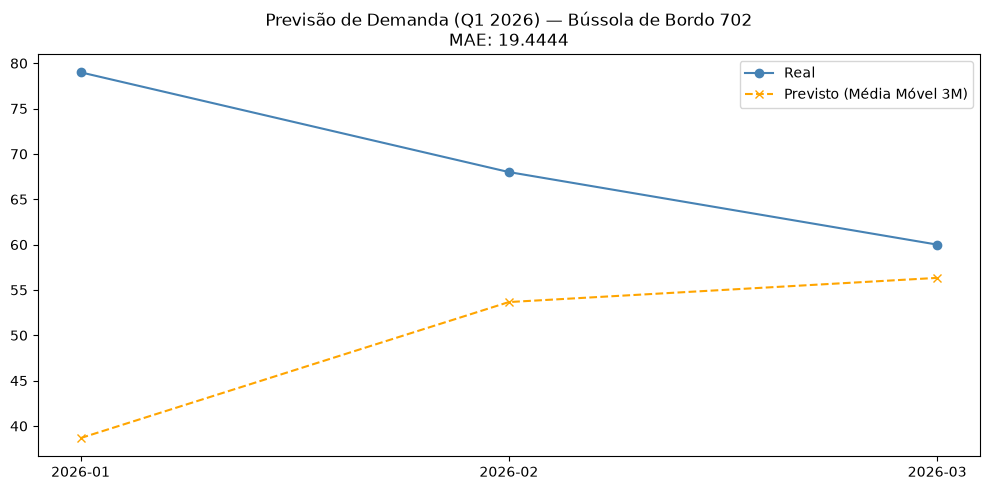

In [50]:
# Calcula o Erro Absoluto Médio (MAE)
mae = mean_absolute_error(teste['qtd'], teste['previsao'])
print(f"\nMAE (Q1 2026): {mae:.4f} unidades/mês")

# Cria o diretório de relatórios, gera e salva o gráfico
os.makedirs('../docs/reports', exist_ok=True)
teste['ano_mes_str'] = teste['ano_mes'].astype(str)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    teste['ano_mes_str'],
    teste['qtd'],
    label='Real',
    color='steelblue',
    marker='o',
)
ax.plot(
    teste['ano_mes_str'],
    teste['previsao'],
    label='Previsto (Média Móvel 3M)',
    color='orange',
    linestyle='--',
    marker='x',
)
ax.set_title(
    f'Previsão de Demanda (Q1 2026) — Bússola de Bordo 702\nMAE: {mae:.4f}'
)
ax.legend()
plt.tight_layout()
plt.savefig('../docs/reports/previsao_demanda_bussola_q1_2026.png', dpi=150)
plt.show()

In [51]:
# Exibe o resumo executivo final
print(f"Soma Real no Trimestre: {teste['qtd'].sum():.0f} unidades")
print(f"Soma Prevista no Trimestre: {round(teste['previsao'].sum())} unidades")

Soma Real no Trimestre: 207 unidades
Soma Prevista no Trimestre: 149 unidades
